## I modified from this code
https://github.com/nattaponm/radar_mosaic_thai_SF66/blob/main/14%E0%B8%9E%E0%B8%A5%E0%B8%AD%E0%B8%95%E0%B8%A0%E0%B8%B2%E0%B8%9E%E0%B9%80%E0%B8%A3%E0%B8%94%E0%B8%B2%E0%B8%A3%E0%B9%8C%E0%B9%82%E0%B8%A1%E0%B9%80%E0%B8%AA%E0%B8%84%E0%B8%A3%E0%B8%B2%E0%B8%A2%E0%B8%8A%E0%B8%B1%E0%B9%88%E0%B8%A7%E0%B9%82%E0%B8%A1%E0%B8%87%E0%B8%97%E0%B8%B1%E0%B9%89%E0%B8%87%E0%B9%80%E0%B8%94%E0%B8%B5%E0%B9%88%E0%B8%A2%E0%B8%A7%E0%B9%81%E0%B8%A5%E0%B8%B0%E0%B8%A0%E0%B8%B2%E0%B8%9E%E0%B8%81%E0%B8%A5%E0%B8%B8%E0%B9%88%E0%B8%A18%E0%B8%A0%E0%B8%B2%E0%B8%9E.ipynb

Mounted at /content/drive
Checking paths...
DATA_ROOT exists    : True
BASE_DIR exists     : True
SHAPEFILE exists    : True
Target .tif exists  : True
Target file         : /content/drive/MyDrive/1shared_etc/000อบรมเรดาร์กรมชลประทาน/0data_radar_mos/0radar_mosaic_geotif_samples/0mfb/2018071722.tif
GeoTIFF files found : 48
First file          : 2018071700.tif
Last file           : 2018071823.tif
✅ Loading: 2018071722.tif ...
Building radar mask...
Plotting map...


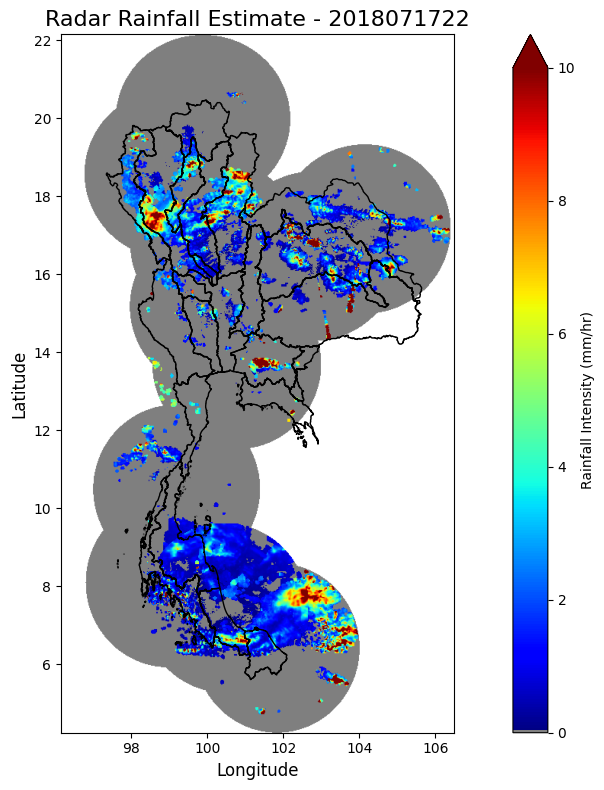

In [1]:
# ============================================================
# CELL 1 - Install required libraries
# ============================================================
!pip install rasterio geopandas pyproj -q


# ============================================================
# CELL 2 - Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
# CELL 3 - Import libraries
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import rasterio
from rasterio.features import rasterize
import geopandas as gpd
from shapely.geometry import Polygon
from pyproj import Geod

%matplotlib inline


# ============================================================
# CELL 4 - Set paths  (TRAINEES: only edit this cell)
# ============================================================

DATA_ROOT = "/content/drive/MyDrive/1shared_etc/000อบรมเรดาร์กรมชลประทาน/0data_radar_mos"

BASE_DIR        = f"{DATA_ROOT}/0radar_mosaic_geotif_samples/0mfb"
BASIN_SHAPEFILE = f"{DATA_ROOT}/0base_map_gis/MainBasin_ONWR_Law_WGS84Geo.shp"

TIME_HR = "2018071722"  # ← change this to any single hour you want to plot


# ============================================================
# CELL 5 - Verify paths (run this before main code!)
# ============================================================
print("=" * 50)
print("Checking paths...")
print(f"DATA_ROOT exists    : {os.path.exists(DATA_ROOT)}")
print(f"BASE_DIR exists     : {os.path.exists(BASE_DIR)}")
print(f"SHAPEFILE exists    : {os.path.exists(BASIN_SHAPEFILE)}")

# Check target .tif file exists
target_file = os.path.join(BASE_DIR, f"{TIME_HR}.tif")
print(f"Target .tif exists  : {os.path.exists(target_file)}")
print(f"Target file         : {target_file}")

if os.path.exists(BASE_DIR):
    tif_files = sorted([f for f in os.listdir(BASE_DIR) if f.endswith('.tif')])
    print(f"GeoTIFF files found : {len(tif_files)}")
    if tif_files:
        print(f"First file          : {tif_files[0]}")
        print(f"Last file           : {tif_files[-1]}")
else:
    print("❌ BASE_DIR not found — check shortcut path")
print("=" * 50)


# ============================================================
# CELL 6 - Define all functions
# ============================================================

def read_geotiff(file_path):
    with rasterio.open(file_path) as src:
        return src.read(1), src.transform, src.crs


def create_geodetic_radar_buffers(radar_dict, active_radars, radius_km, crs):
    geod = Geod(ellps="WGS84")
    azimuths = np.linspace(0, 360, 361)

    radar_data = [
        {'radar': radar, 'geometry': Polygon([
            geod.fwd(*radar_dict[radar]['coords'][:2], azimuth, radius_km * 1000)[:2]
            for azimuth in azimuths
        ])}
        for radar in active_radars
    ]

    return gpd.GeoDataFrame(radar_data, crs=crs)


def create_radar_mask(radar_buffers, shape, transform, crs):
    return rasterize(
        [(geom, 1) for geom in radar_buffers.geometry],
        out_shape=shape,
        transform=transform,
        fill=0,
        dtype=np.uint8
    )


def plot_rainfall_map(data, radar_mask, transform, crs, basin_shapefile, time_hr, vmin=0, vmax=10):
    cmap = plt.cm.jet
    jet_colors = cmap(np.linspace(0, 1, 256))
    jet_colors[0] = [0.5, 0.5, 0.5, 1]  # grey for 0 mm
    custom_cmap = ListedColormap(jet_colors)
    custom_cmap.set_bad('white')          # white outside radar mask

    masked_data = np.ma.masked_where(radar_mask == 0, data)

    fig, ax = plt.subplots(figsize=(12, 8))
    extent = rasterio.transform.array_bounds(data.shape[0], data.shape[1], transform)
    extent = [extent[0], extent[2], extent[1], extent[3]]

    im = ax.imshow(masked_data, cmap=custom_cmap, extent=extent,
                   origin='upper', vmin=vmin, vmax=vmax)

    gdf = gpd.read_file(basin_shapefile)
    gdf.to_crs(crs).boundary.plot(ax=ax, color='black', linewidth=1)

    plt.colorbar(im, ax=ax, extend='max', label='Rainfall Intensity (mm/hr)')
    ax.set_title(f'Radar Rainfall Estimate - {time_hr}', fontsize=16)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_xlim(96.15, 106.5)
    ax.set_ylim(4.25, 22.15)

    plt.tight_layout()
    plt.show()


def main(time_hr, base_dir, basin_shapefile, radar_dict, radius_km=240):

    file_path = os.path.join(base_dir, f"{time_hr}.tif")

    if not os.path.exists(file_path):
        print(f"❌ File not found: {file_path}")
        return

    # Use all radars (no mosaic report needed)
    available_radars = list(radar_dict.keys())

    print(f"✅ Loading: {time_hr}.tif ...")
    data, transform, crs = read_geotiff(file_path)

    print("Building radar mask...")
    radar_buffers = create_geodetic_radar_buffers(radar_dict, available_radars, radius_km, crs)
    radar_mask = create_radar_mask(radar_buffers, data.shape, transform, crs)

    print("Plotting map...")
    plot_rainfall_map(data, radar_mask, transform, crs, basin_shapefile, time_hr)


# ============================================================
# CELL 7 - Radar dictionary
# ============================================================
radar_dict = {
    "CHN": {'coords': (100.191263, 15.157852, 40.0)},
    "CMP": {'coords': (99.188203,  10.493099, 32.0)},
    "CRI": {'coords': (99.881593,  19.961471, 444.0)},
    "KKN": {'coords': (102.785881, 16.4625,   217.0)},
    "KRB": {'coords': (98.97806,   8.101389,  52.0)},
    "LMP": {'coords': (99.041701,  18.565399, 320.0)},
    "NRT": {'coords': (101.825165, 6.426888,  33.0)},
    "PHS": {'coords': (100.217964, 16.775408, 72.0)},
    "PKT": {'coords': (98.329444,  8.133611,  281.0)},
    "SNK": {'coords': (104.132591, 17.156363, 196.0)},
    "STP": {'coords': (100.459996, 7.449996,  33.0)},
    "SVP": {'coords': (100.7675,   13.686389, 28.0)},
}


# ============================================================
# CELL 8 - RUN!
# ============================================================
main(TIME_HR, BASE_DIR, BASIN_SHAPEFILE, radar_dict)